In [10]:
# === Paso 1: Setup: imports, rutas, listar archivos ===
import os
from pathlib import Path
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

abs_path = os.path.abspath(os.getcwd())
ROOT_DIRECTORY = os.path.abspath(os.path.join(abs_path, '..', ".."))
data_folder = os.path.join(ROOT_DIRECTORY, "data", "raw")

print("Data folder:", data_folder)
print("Archivos disponibles:")
for f in sorted(os.listdir(data_folder)):
    print(f"  {f}")

Data folder: /Users/David/Documents/academia/doctorado/egofets_poject/data/raw
Archivos disponibles:
  2026-06-26_test1.hdf5
  2026-06-29_test2.1.hdf5
  2026-06-29_test2.2.hdf5
  2026-06-29_test2.hdf5
  2026-06-30_test3.hdf5


In [11]:
# === Paso 2: Abrir HDF5 y listar SOLO los grupos top-level (mediciones) ===
# Cada grupo top-level es una medicion distinta (transfer, output, o stability)

file_name = "2026-06-26_test1.hdf5"
file_path = os.path.join(data_folder, file_name)

with h5py.File(file_path, 'r') as f:
    print(f"Archivo: {file_name}")
    print(f"Mediciones encontradas ({len(f.keys())}):\n")
    for name in sorted(f.keys()):
        group = f[name]
        mode = group.attrs.get('measurement_mode', 'desconocido')
        n_curves = len([k for k in group.keys() if k.startswith('curve_')])
        print(f"  {name:50s}  mode={mode:10s}  curves={n_curves}")

Archivo: 2026-06-26_test1.hdf5
Mediciones encontradas (39):

  Batch1_Dispositivo1_Output1_00                      mode=output      curves=7
  Batch1_Dispositivo1_Output2_00                      mode=output      curves=7
  Batch1_Dispositivo1_Transfer1_00                    mode=transfer    curves=2
  Batch1_Dispositivo1_Transfer1_01                    mode=transfer    curves=2
  Batch1_Dispositivo1_Transfer2_00                    mode=transfer    curves=2
  Batch1_Dispositivo2_Output_00                       mode=output      curves=7
  Batch1_Dispositivo2_Output_01                       mode=output      curves=7
  Batch1_Dispositivo2_Output_02                       mode=transfer    curves=2
  Batch1_Dispositivo2_Output_03                       mode=output      curves=7
  Batch1_Dispositivo2_Transfer1_00                    mode=transfer    curves=2
  Batch1_Dispositivo2_Transfer2_00                    mode=transfer    curves=2
  Batch1_Dispositivo2_Transfer2_01                    mode=

In [12]:
# === Paso 3: Leer UNA sola curva ===
# Crucial: acceder con '[:]' convierte el dataset de h5py en un numpy array

with h5py.File(file_path, 'r') as f:
    # Transfer sin histéresis: 81 puntos, solo ida
    curve = f['Batch1_Dispositivo1_Transfer1_00']['curve_000']
    v_gs = curve['measured_V_GS'][:]
    i_ds = curve['measured_I_DS'][:]

print(f"Tipo de v_gs: {type(v_gs)}")
print(f"Shape: {v_gs.shape}")
print(f"Primeros 5 valores de V_GS: {v_gs[:5]}")
print(f"Primeros 5 valores de I_DS: {i_ds[:5]}")

Tipo de v_gs: <class 'numpy.ndarray'>
Shape: (81,)
Primeros 5 valores de V_GS: [0.400357 0.390179 0.380359 0.370169 0.360327]
Primeros 5 valores de I_DS: [-2.31166e-07 -2.34337e-07 -2.27624e-07 -2.21223e-07 -2.13913e-07]


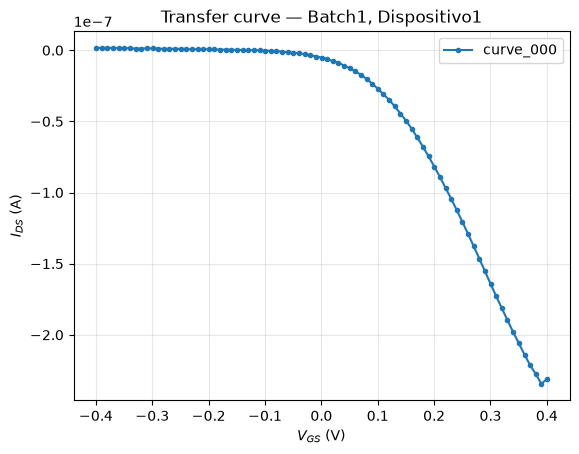

In [13]:
# === Paso 4: Primer grafico simple: I_DS vs V_GS ===
# 'o-' = circulos unidos por lineas (o = marker, - = line)
# Si solo hubiera forward (sin reverse), se veria una curva limpia

with h5py.File(file_path, 'r') as f:
    v_gs = f['Batch1_Dispositivo1_Transfer1_00']['curve_000']['measured_V_GS'][:]
    i_ds = f['Batch1_Dispositivo1_Transfer1_00']['curve_000']['measured_I_DS'][:]

fig, ax = plt.subplots()
ax.plot(v_gs, i_ds, 'o-', ms=3, label='curve_000')
ax.set_xlabel(r"$V_{GS}$ (V)")
ax.set_ylabel(r"$I_{DS}$ (A)")
ax.set_title("Transfer curve — Batch1, Dispositivo1")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

In [14]:
# === Paso 5: Detectar forward vs reverse en V_GS ===
# Cuando V_GS va en una direccion y luego en la contraria,
# np.diff(v_gs) cambia de signo. Ese punto es el 'quiebre'.

with h5py.File(file_path, 'r') as f:
    v_gs = f['Batch1_Dispositivo1_Transfer2_00']['curve_000']['measured_V_GS'][:]
    i_ds = f['Batch1_Dispositivo1_Transfer2_00']['curve_000']['measured_I_DS'][:]

print(f"Total de puntos: {len(v_gs)}")

# Detectamos el cambio de direccion
diff = np.diff(v_gs)                  # diferencia entre puntos consecutivos
signs = np.sign(diff)                 # +1 si crece, -1 si decrece
signs = signs[signs != 0]             # quitamos ceros (mesetas)

# Buscamos donde cambia el signo
change_mask = np.diff(signs) != 0
change_indices = np.where(change_mask)[0]

if len(change_indices) == 0:
    print("Monotonico — sin cambio de direccion (no hay reverse)")
else:
    split_idx = change_indices[0] + 1  # indice del cambio en V_GS original
    print(f"Cambio de direccion en el indice {split_idx} / {len(v_gs)}")
    print(f"  Forward: indices 0 -> {split_idx}   ({split_idx+1} puntos)")
    print(f"  Reverse: indices {split_idx+1} -> {len(v_gs)-1}")
    print(f"  V_GS alrededor del quiebre: {v_gs[split_idx-2:split_idx+3]}")

Total de puntos: 162
Cambio de direccion en el indice 81 / 162
  Forward: indices 0 -> 81   (82 puntos)
  Reverse: indices 82 -> 161
  V_GS alrededor del quiebre: [-0.389624 -0.399489 -0.399516 -0.38965  -0.379767]


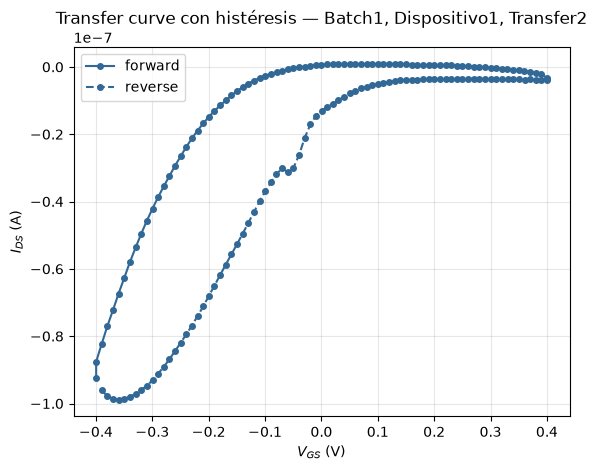

In [15]:
# === Paso 6: Graficar forward y reverse por separado (histéresis visible) ===
# Colores: forward = trazo solido oscuro, reverse = mismo color pero discontinuo
# Asi se ve que son la misma curva (mismo V_DS) en dos direcciones distintas

with h5py.File(file_path, 'r') as f:
    v_gs = f['Batch1_Dispositivo1_Transfer2_00']['curve_000']['measured_V_GS'][:]
    i_ds = f['Batch1_Dispositivo1_Transfer2_00']['curve_000']['measured_I_DS'][:]

# Detectar el quiebre (repetimos la logica del paso 5)
signs = np.sign(np.diff(v_gs))
signs = signs[signs != 0]
split_idx = np.where(np.diff(signs) != 0)[0][0] + 1

# Separar en dos segmentos
v_gs_fwd = v_gs[:split_idx+1]
i_ds_fwd = i_ds[:split_idx+1]
v_gs_rev = v_gs[split_idx+1:]
i_ds_rev = i_ds[split_idx+1:]

fig, ax = plt.subplots()
# Mismo color base (#326896), diferente estilo de linea
color_fwd = '#326896'
ax.plot(v_gs_fwd, i_ds_fwd, 'o-',  ms=4, color=color_fwd, label='forward')
ax.plot(v_gs_rev, i_ds_rev, 'o--', ms=4, color=color_fwd, label='reverse')
ax.set_xlabel(r"$V_{GS}$ (V)")
ax.set_ylabel(r"$I_{DS}$ (A)")
ax.set_title("Transfer curve con histéresis — Batch1, Dispositivo1, Transfer2")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

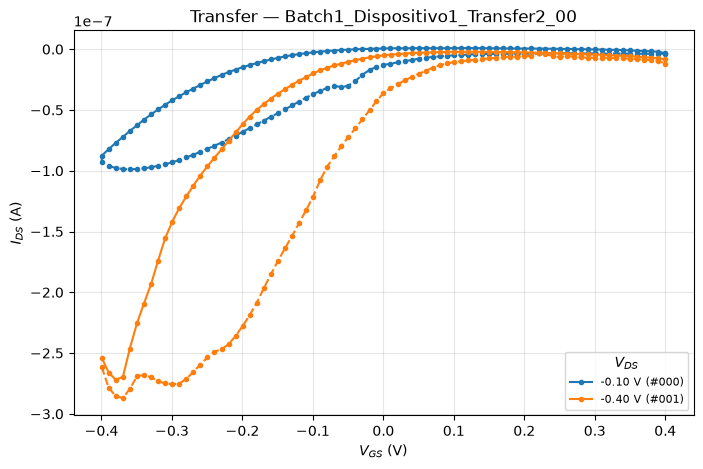

In [18]:
# === Paso 7: Iterar sobre todas las curvas de una medicion ===
# Cada curve_NNN corresponde a un V_DS distinto (en transfer)
# Mismo color para forward/reverse de un mismo V_DS;
# solido = forward, discontinuo = reverse.

def has_hysteresis(v_gs):
    """Devuelve el indice de quiebre si la curva tiene forward+reverse, o None."""
    signs = np.sign(np.diff(v_gs))
    signs = signs[signs != 0]
    changes = np.where(np.diff(signs) != 0)[0]
    if len(changes) == 0:
        return None
    return changes[0] + 1

colors = plt.cm.tab10.colors  # paleta de 10 colores bien distinguibles

group_name = "Batch1_Dispositivo1_Transfer2_00"

fig, ax = plt.subplots(figsize=(8, 5))

with h5py.File(file_path, 'r') as f:
    curve_names = sorted(f[group_name].keys())
    
    for i, curve_name in enumerate(curve_names):
        v_gs = f[group_name][curve_name]['measured_V_GS'][:]
        i_ds = f[group_name][curve_name]['measured_I_DS'][:]
        v_ds = f[group_name][curve_name].attrs.get('V_DS', '?')
        
        curve_idx = curve_name.split('_')[-1]
        color = colors[i % len(colors)]
        
        split = has_hysteresis(v_gs)
        if split is None:
            # Solo una direccion
            ax.plot(v_gs, i_ds, 'o-', ms=3, color=color,
                    label=f'{float(v_ds):.2f} V (#{curve_idx})')
        else:
            # Forward + reverse: mismo color, distinto estilo
            ax.plot(v_gs[:split+1], i_ds[:split+1], 'o-', ms=3,
                    color=color, label=f'{float(v_ds):.2f} V (#{curve_idx})')
            ax.plot(v_gs[split+1:], i_ds[split+1:], 'o--', ms=3,
                    color=color, label='_nolegend_')

ax.set_xlabel(r"$V_{GS}$ (V)")
ax.set_ylabel(r"$I_{DS}$ (A)")
ax.set_title(f"Transfer — {group_name}")
ax.legend(fontsize=8, title=r'$V_{DS}$')
ax.grid(True, alpha=0.3)
plt.show()